In [2]:
import pandas as pd
import numpy as np

data = {
    "Food_Item": [
        "AlooGobi", "AlooMasala", "Bhatura", "BhindiMasala", "Biryani",
        "Chai", "Chole", "CoconutChutney", "Dal", "Dosa",
        "DumAloo", "FishCurry", "Ghevar", "GreenChutney", "GulabJamun",
        "Idli", "Jalebi", "Kebab", "Kheer", "Kulfi",
        "Lassi", "MuttonCurry", "OnionPakoda", "PalakPaneer", "Poha",
        "RajmaCurry", "RasMalai", "Samosa", "ShahiPaneer", "WhiteRice"
    ],
    "Calories_per_Gram_kcal": [
        0.90, 1.10, 3.10, 1.20, 1.80,
        0.50, 1.60, 3.00, 1.10, 1.70,
        1.80, 1.50, 4.20, 0.80, 3.80,
        1.30, 4.00, 2.50, 1.40, 2.60,
        0.80, 2.20, 3.20, 1.90, 1.30,
        1.50, 2.40, 2.90, 2.60, 1.30
    ]
}

df = pd.DataFrame(data)

# Approximate standard serving weights (grams) for fixed-size items
serving_weights = {
    "Bhatura": 100,
    "Dosa": 120,
    "Ghevar": 80,
    "GulabJamun": 40,
    "Idli": 50,
    "Jalebi": 35,
    "Kebab": 100,
    "Kulfi": 90,
    "Lassi": 250,        # ml ≈ g
    "OnionPakoda": 80,
    "RasMalai": 100,
    "Samosa": 120
}

# Create per-serving column
df["Calories_per_Serving_kcal"] = df.apply(
    lambda row: row["Calories_per_Gram_kcal"] * serving_weights[row["Food_Item"]]
    if row["Food_Item"] in serving_weights
    else np.nan,
    axis=1
)

df

,Food_Item,Calories_per_Gram_kcal,Calories_per_Serving_kcal
0,AlooGobi,0.9,NaN
1,AlooMasala,1.1,NaN
2,Bhatura,3.1,310.0
3,BhindiMasala,1.2,NaN
4,Biryani,1.8,NaN
5,Chai,0.5,NaN
6,Chole,1.6,NaN
7,CoconutChutney,3.0,NaN
8,Dal,1.1,NaN
9,Dosa,1.7,204.0


In [4]:
from ultralytics import YOLO



model = YOLO(r"C:\Users\ASUS\Documents\Study\Major\Project\runs\detect\train2\weights\best.pt")

results = model.predict(
    source="images2.jpg",
    save=False,
    show=False
)

result = results[0]
boxes = result.boxes



image 1/1 c:\Users\ASUS\Documents\Study\Major\Project\Calories\images2.jpg: 384x640 2 Bhaturas, 1 Chole, 90.5ms
Speed: 15.2ms preprocess, 90.5ms inference, 4.1ms postprocess per image at shape (1, 3, 384, 640)


In [6]:
calorie_df = df # your dataframe saved as CSV

for box in boxes:
    cls_id = int(box.cls[0])
    class_name = model.names[cls_id]

    x1, y1, x2, y2 = box.xyxy[0].cpu().numpy()
    width = x2 - x1
    height = y2 - y1

    pixel_area = width * height

    print(class_name, pixel_area)

Bhatura 80887.01
Bhatura 155199.6
Chole 90727.08


In [7]:
reference_area = 15000  # example average pixel area of 1 samosa
reference_weight = 120  # grams

grams_per_pixel = reference_weight / reference_area

estimated_weight = pixel_area * grams_per_pixel

In [8]:
kcal_per_gram = calorie_df.loc[
    calorie_df["Food_Item"] == class_name,
    "Calories_per_Gram_kcal"
].values[0]

estimated_calories = estimated_weight * kcal_per_gram

print(f"{class_name}: {estimated_calories:.2f} kcal")

Chole: 1161.31 kcal


In [9]:
object_count = len(boxes)

per_serving_kcal = calorie_df.loc[
    calorie_df["Food_Item"] == class_name,
    "Calories_per_Serving_kcal"
].values[0]

estimated_calories = object_count * per_serving_kcal

In [16]:
from ultralytics import YOLO

# Load a segmentation model
model = YOLO("yolov8l-seg.pt")

# Perform inference
results = model.predict("images2.jpg")

# Each result now includes masks
for r in results:
    masks = r.masks  # binary masks


image 1/1 c:\Users\ASUS\Documents\Study\Major\Project\Calories\images2.jpg: 384x640 1 person, 1 cup, 1 spoon, 1 bowl, 2 sandwichs, 1 dining table, 527.9ms
Speed: 2.1ms preprocess, 527.9ms inference, 5.1ms postprocess per image at shape (1, 3, 384, 640)


In [14]:
r.plot()

array([[[ 63, 207, 160],
        [ 54, 208, 158],
        [ 51, 205, 154],
        ...,
        [211, 196, 193],
        [211, 196, 193],
        [211, 196, 193]],

       [[ 11, 255, 162],
        [ 11, 255, 162],
        [ 35, 234, 146],
        ...,
        [211, 196, 193],
        [211, 196, 193],
        [211, 196, 193]],

       [[ 11, 255, 162],
        [109, 170,  98],
        [255,  42,   4],
        ...,
        [211, 196, 193],
        [211, 196, 193],
        [211, 196, 193]],

       ...,

       [[ 80,  85,  86],
        [ 79,  84,  85],
        [ 78,  83,  84],
        ...,
        [ 94,  96,  96],
        [ 94,  96,  96],
        [ 94,  96,  96]],

       [[ 83,  88,  89],
        [ 82,  87,  88],
        [ 81,  86,  87],
        ...,
        [ 96,  98,  98],
        [ 95,  97,  97],
        [ 95,  97,  97]],

       [[ 84,  89,  90],
        [ 84,  89,  90],
        [ 82,  87,  88],
        ...,
        [ 97,  99,  99],
        [ 96,  98,  98],
        [ 96,  98,  98]]


image 1/1 c:\Users\ASUS\Documents\Study\Major\Project\Calories\images2.jpg: 384x640 1 bottle, 1 bowl, 1 sandwich, 1 carrot, 1 dining table, 196.6ms
Speed: 2.1ms preprocess, 196.6ms inference, 5.6ms postprocess per image at shape (1, 3, 384, 640)


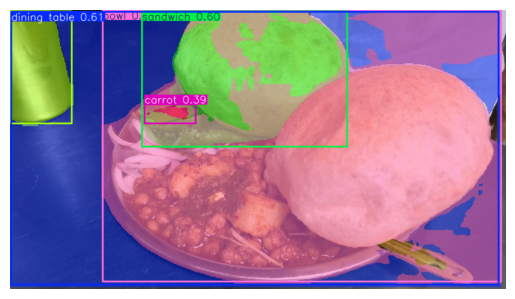

In [15]:
import matplotlib.pyplot as plt
import cv2

# Run prediction
results = model.predict("images2.jpg")

# Get first result
r = results[0]

# Get annotated image (BGR)
annotated = r.plot()

# Convert BGR → RGB for matplotlib
annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

# Display
plt.imshow(annotated_rgb)
plt.axis("off")
plt.show()


image 1/1 c:\Users\ASUS\Documents\Study\Major\Project\Calories\images4.jpg: 448x640 1 bowl, 1 dining table, 591.7ms
Speed: 2.6ms preprocess, 591.7ms inference, 3.5ms postprocess per image at shape (1, 3, 448, 640)


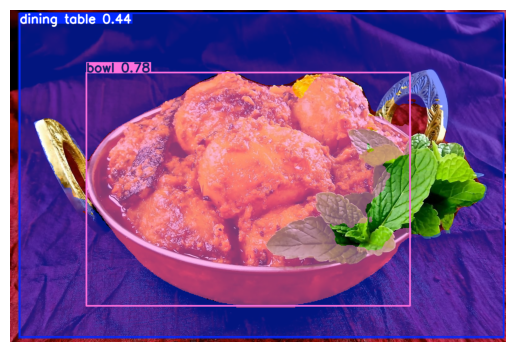

In [ ]:
import matplotlib.pyplot as plt
import cv2

results = model.predict("images4.jpg")
r = results[0]
annotated = r.plot()

annotated_rgb = cv2.cvtColor(annotated, cv2.COLOR_BGR2RGB)

plt.imshow(annotated_rgb)
plt.axis("off")
plt.show()